<a href="https://colab.research.google.com/github/Ranjan659/Cardamom-leaf-classifier/blob/main/notebooks/01_data_setup_visualizaton.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Cardamom Leaf vs Not-Leaf Classification

## Phase 1: Data Loading Pipeline

### Objectives
In this notebook we will:

1. Connect Google Drive to Colab
2. Load image dataset
3. Apply preprocessing transforms
4. Create batches using DataLoader
5. Visualize sample images

This is the first step before training a CNN model.

In [15]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Importing Required Libraries

We import:

- `torch` → Deep learning framework
- `torchvision` → Image datasets and transforms
- `matplotlib` → Visualization
- `os` → File handling

In [16]:
import os
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Dataset Setup

Dataset stored in Google Drive:

```text
cardamom_dataset/
└── train/
    ├── leaf/
    └── not_leaf/
```

We store the dataset location in:

```python
DATA_PATH = "/content/drive/MyDrive/cardamom_dataset/train"
```

This path tells PyTorch:

- "Go inside Google Drive"  
- "Find the dataset folder"  
- "Load images from the `train` directory"

---



In [17]:
DATA_PATH = "/content/drive/MyDrive/cardamom_dataset/train"

# Image Preprocessing

Neural networks require images of the same size.

We apply:

- `Resize(224,224)` → Standard input size
- `ToTensor()` → Converts image into tensor

In [18]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

#Load Dataset

`ImageFolder` reads all images and assigns labels automatically.

#How `ImageFolder` Works

`ImageFolder` automatically:

- Reads all images inside each folder  
- Uses folder names as class labels  
- Assigns numerical labels automatically

Example:

| Folder Name | Assigned Label |
|---|---|
| `leaf` | `0` |
| `not_leaf` | `1` |

So:

- Every image inside `leaf/` becomes class `0`
- Every image inside `not_leaf/` becomes class `1`

This makes dataset loading very easy for image classification tasks.

In [19]:
cardamom_leaves_dataset = datasets.ImageFolder(
    root=DATA_PATH,
    transform=transform
)

print("✅ Classes:", cardamom_leaves_dataset.classes)
print("✅ Label Mapping:", cardamom_leaves_dataset.class_to_idx)
print("✅ Total Images:", len(cardamom_leaves_dataset))

✅ Classes: ['leaf', 'not_leaf']
✅ Label Mapping: {'leaf': 0, 'not_leaf': 1}
✅ Total Images: 60


# Create DataLoader

The DataLoader:

- Creates batches
- Shuffles data
- Feeds images during training

Batch size = 8 means:
8 images are processed together.

In [20]:
dataloader = torch.utils.data.DataLoader(
    cardamom_leaves_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

# Inspect One Batch

We fetch one batch to verify:

- image shape
- labels
- preprocessing

In [21]:
images, labels = next(iter(dataloader))

print("✅ Batch Shape:", images.shape)
print("✅ Labels:", labels)

✅ Batch Shape: torch.Size([8, 3, 224, 224])
✅ Labels: tensor([0, 0, 0, 0, 1, 1, 1, 1])


# Visualize Images

PyTorch stores images in this format:

```text
(C, H, W)
```

Where:

- `C` → Color Channels  
  (`3` for RGB images)

- `H` → Image Height  
  (number of pixels vertically)

- `W` → Image Width  
  (number of pixels horizontally)

Example:

```text
(3, 224, 224)
```

means:

- 3 color channels (Red, Green, Blue)
- Height = 224 pixels
- Width = 224 pixels

However, `matplotlib` expects images in this format:

```text
(H, W, C)
```

So we use:

```python
permute(1, 2, 0)
```

to rearrange the dimensions before displaying the image.

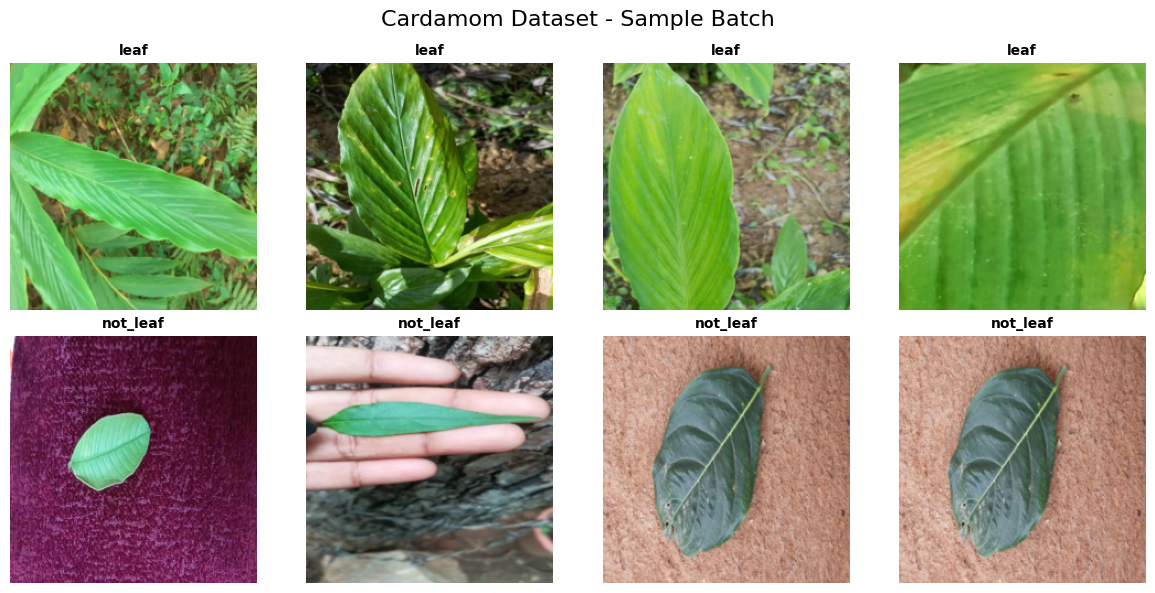

In [22]:
# Convert tensor into displayable image
def tensor_to_image(tensor):

    # Rearrange dimensions for display
    image = tensor.permute(1, 2, 0)

    # Keep pixel values between 0 and 1
    image = image.clamp(0, 1)

    return image

# Create figure and subplot grid with 2 rows and 4 columns
# figsize controls overall plot size
fig, axes = plt.subplots(
    2,
    4,
    figsize=(12, 6)
)


# axes contains all subplot boxes

# axes.flat converts the 2D grid into a simple 1D sequence for easier looping
# enumerate() adds index numbers:

# idx = image number
# ax  = current plot box
for idx, ax in enumerate(axes.flat):

    # Prevents going outside image list
    if idx < len(images):

        # Display image in current subplot
        ax.imshow(
            tensor_to_image(images[idx])
        )

        # Convert numeric label into class name
        class_name = (
            cardamom_leaves_dataset.classes[
                labels[idx]
            ]
        )

        # Add title above image
        ax.set_title(
            class_name,
            fontsize=10,
            fontweight="bold"
        )

        # Hide x-axis and y-axis
        ax.axis("off")


# Add title for entire figure
plt.suptitle(
    "Cardamom Dataset - Sample Batch",
    fontsize=16
)

# Automatically adjust spacing
# Prevents overlap between plots
plt.tight_layout()

# Display final visualization
plt.show()

# Step 2: Building a Tiny CNN Model

In this step, we create a small Convolutional Neural Network (CNN) for binary image classification.

The model will learn to classify:

- `leaf`
- `not_leaf`

### CNN Architecture

```text
Input Image
      ↓
Convolution Layers
      ↓
ReLU Activation
      ↓
Max Pooling
      ↓
Flatten
      ↓
Fully Connected Layers
      ↓
Prediction Output
```

The network contains:

- 3 Convolution layers → feature extraction
- MaxPooling → reduce image size
- Fully Connected layers → final classification

In [23]:
# Neural network module
import torch.nn as nn

# Functional operations like ReLU
import torch.nn.functional as F

#Defining CNN Architecture

The CNN learns image patterns step-by-step.

### What each layer does:

| Layer | Purpose |
|---|---|
| Conv2D | Detect features like edges, textures |
| ReLU | Adds non-linearity |
| MaxPool | Reduces image size |
| Flatten | Converts 2D features into 1D vector |
| Linear | Final classification |

The image size changes after pooling:

```text
224 × 224
    ↓
112 × 112
    ↓
56 × 56
    ↓
28 × 28
```

In [24]:
class TinyCardamomCNN(nn.Module):

    def __init__(self):

        # Initialize parent class
        super(TinyCardamomCNN, self).__init__()

        # ==================================================
        # Convolution Layers
        # ==================================================
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            16,
            32,
            kernel_size=3,
            padding=1
        )

        self.conv3 = nn.Conv2d(
            32,
            64,
            kernel_size=3,
            padding=1
        )


        # ==================================================
        # Pooling Layer
        # ==================================================

        # Reduces width and height by half
        #
        # Example:
        # 224 → 112
        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )


        # ==================================================
        # Fully Connected Layers
        # ==================================================

        # After 3 poolings:
        #
        # 224 → 112 → 56 → 28
        #
        # Final tensor:
        # [64, 28, 28]
        #
        # Flattened size:
        # 64 × 28 × 28 = 50176
        self.fc1 = nn.Linear(
            64 * 28 * 28,
            32
        )


        # Final output layer
        #
        # Output:
        # 1 value for binary classification
        self.fc2 = nn.Linear(
            32,
            1
        )


    # ======================================================
    # Forward Pass
    # ======================================================

    def forward(self, x):

        # Conv → ReLU → Pool
        x = self.pool(
            F.relu(self.conv1(x))
        )

        # Shape:
        # [batch, 16, 112, 112]


        # Conv → ReLU → Pool
        x = self.pool(
            F.relu(self.conv2(x))
        )

        # Shape:
        # [batch, 32, 56, 56]


        # Conv → ReLU → Pool
        x = self.pool(
            F.relu(self.conv3(x))
        )

        # Shape:
        # [batch, 64, 28, 28]


        # Flatten tensor
        #
        # Example:
        # [8, 64, 28, 28]
        # →
        # [8, 50176]
        x = x.view(-1, 64 * 28 * 28)


        # Fully connected layer
        x = F.relu(self.fc1(x))


        # Final prediction
        x = self.fc2(x)

        return x

# Create Model Instance

Now we create an object of the CNN class.

This initializes all layers and prepares the network for training.

In [25]:
# Create model object
model = TinyCardamomCNN()

print("✅ Model created successfully!")

# Print architecture
print("\n📊 Model Architecture:\n")
print(model)

✅ Model created successfully!

📊 Model Architecture:

TinyCardamomCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=50176, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)


#Count Model Parameters

Neural networks learn using trainable parameters.

More parameters usually mean:

- more learning capacity
- but also higher risk of overfitting

We calculate:

- Total parameters
- Trainable parameters

In [26]:
# Count all parameters
total_params = sum(
    p.numel()
    for p in model.parameters()
)

# Count trainable parameters only
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"\n📈 Total parameters: {total_params:,}")
print(f"📈 Trainable parameters: {trainable_params:,}")


📈 Total parameters: 1,629,281
📈 Trainable parameters: 1,629,281


#Testing Forward Pass

Before training, we test whether the model works correctly.

We create a fake image tensor and pass it through the network.

This helps catch shape errors early.

In [27]:
# Create fake image
#
# Shape:
# [batch, channels, height, width]
test_input = torch.randn(
    1,
    3,
    224,
    224
)

# Pass image through model
output = model(test_input)

print("\n✅ Forward pass successful!")

print(f"\nInput shape: {test_input.shape}")

print(f"Output shape: {output.shape}")

print(
    f"Output value: "
    f"{output.item():.4f}"
)


✅ Forward pass successful!

Input shape: torch.Size([1, 3, 224, 224])
Output shape: torch.Size([1, 1])
Output value: -0.0872
